In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot



In [ ]:
transacoes = pd.read_csv("data/transacoes.csv", sep=';')

In [ ]:
produtos = pd.read_csv("data/produtos.csv", sep=';')

In [ ]:
clientes = pd.read_csv("data/clientes.csv", sep=';')

In [ ]:
clientes.head()

In [ ]:
clientes.to_json("clientes.json", index=False)

### Copiando os dados do Control + C -> Control + V (arquivo bobo.csv)

In [ ]:
df = pd.read_clipboard(sep=',')

### Usando arquivos de páginas HTML

In [ ]:
# url = "https://pt.wikipedia.org/wiki/Unidades_federativas_do_Brasil"
# estados = pd.read_html(url)
# estados

In [ ]:
url = "https://pt.wikipedia.org/wiki/Unidades_federativas_do_Brasil"

# Definindo um cabeçalho que simula o Chrome
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Lendo as tabelas da página
tabelas = pd.read_html(url, storage_options=headers)

# Geralmente a tabela dos estados é a primeira ou segunda
df_estados = tabelas[1] 
print(df_estados.head())

## Primeiras linhas

In [ ]:
clientes.head(10)

## Últimas linhas

In [ ]:
clientes.tail()

## Uma amostra aleatória

In [ ]:
clientes.sample(5)

## Atributo **shape** para determinar linhas e colunas

In [ ]:
clientes.shape

## Mostrar a lista de colunas

In [ ]:
clientes.columns

## Mostrar os índices. Caso não existe, o pandas cria um índice sequencial

In [ ]:
clientes.index

## Informações gerais

In [ ]:
clientes.info()

O valor de memória alocada é uma estimativa (inferência) determinada pelos tipos de dados do Dataframe. para o valor mais preciso, usaremos uma parâmetro memory_usage='deep'

In [ ]:
clientes.info(memory_usage='deep')

## Detalhamento do tipo das colunas

In [ ]:
clientes.dtypes

In [ ]:
type(clientes.dtypes)

Esse atributo retorna uma série com o tipo preciso de cada coluna. Assim, para verificar um tipo específico de uma coluna.

In [ ]:
clientes.dtypes['flEmail']

## Renomeando colunas

In [ ]:
transacoes.shape

In [ ]:
transacoes.info(memory_usage='deep')

In [ ]:
transacoes.dtypes

Para renomear uma coluna deve ser passado um dicionário: a chave o nome antigo, e o valor com o nome novo.

In [ ]:
transacoes.rename(columns={'QtdePontos': 'qtPontos'})

Essa alteração não reflete diretamente no Dataframe. Isso ocorre porque um novo dataframe é criado em memória com a operação realizada.

In [ ]:
transacoes.head()

Mais de uma alteração

In [ ]:
transacoes.rename(columns={'qtPontos':'QtdePontos' ,
                           'DescSistemaOrigem': 'sistemaOrigem'})

Se for pensar em legibilidade, se pode criar um dicionário separado e depois passá-lo para a função rename.

In [ ]:
colunas_renomeadas = {
    'qtPontos': 'QtdePontos' ,
    'DescSistemaOrigem': 'sistemaOrigem'
}

In [ ]:
transacoes.rename(columns=colunas_renomeadas)

## Realizando a alteração efetivamente no dataframe

Duas formas pode ser usadas:
- Atribuindo novamente ao mesmo dataframe;
- usando o parâmetro inplace=True


In [ ]:
# transacoes = transacoes.rename(columns=colunas_renomeadas, inplace=True)

In [ ]:
type(transacoes)

In [ ]:
transacoes.head(2)

### Navegação no dataframe

In [ ]:
transacoes['IdCliente'].iloc[1:4]

Esse comando retorna um Série do dataframe

In [ ]:
type(transacoes['IdCliente'].iloc[1:4])

### Mais de coluna

In [ ]:
transacoes['IdCliente', 'QtdePontos']

Esse erro ocorre porque apenas um valor (objeto) pode ser passado na navegação. Para isso, é usado uma lista

In [ ]:
transacoes.columns

In [ ]:
transacoes[['IdCliente', 'QtdePontos']]

Agora diferentemente de comandos anteriores, este último comando não retorna uma série, e sim, um novo dataframe. Ele somente será uma Série, e for passado apenas uma coluna do dataframe.

In [ ]:
type(transacoes[['IdCliente', 'QtdePontos']])

### Mesclando os conceitos

In [ ]:
(transacoes[['IdCliente', 'QtdePontos']].sample(10))

## Reordenar as colunas

In [ ]:
transacoes.sample()

### Apenas para exibição

In [ ]:
transacoes[["DescSistemaOrigem","QtdePontos" ,"DtCriacao", "IdCliente"]].sample(7)

In [ ]:
listas_colunas = transacoes.columns.to_list()

In [ ]:
listas_colunas.sort()

In [ ]:
transacoes = transacoes[listas_colunas]

# Aplicando Filtros

In [ ]:
transacoes['QtdePontos'] >= 50

In [ ]:
type(transacoes['QtdePontos'] >= 50)

In [ ]:
filtro = transacoes['QtdePontos'] >= 50
transacoes[filtro]

### Mesclando o conhecimentos

In [ ]:
transacoes[transacoes['QtdePontos'] <= 50].sample(4)

É possível fazer com uma lista. Isso somente é possível por que o filtro tem a mesma dimensão do dataframe.

In [ ]:
filtro = filtro.tolist()
transacoes[filtro]

Para provar que dará erro - passar uma quantidade diferente de dimensões.

In [ ]:
# filtro_errado = [False, True]
# transacoes[filtro_errado]

### Aplicando intervalos

In [ ]:
filtro_intervalo = (transacoes['QtdePontos'] >= 50) & (transacoes['QtdePontos'] < 100)
transacoes[filtro_intervalo].tail()

In [ ]:
transacoes[(transacoes['QtdePontos'] == 1) | (transacoes['QtdePontos'] == 100 )].sample(6)

Na lógica Booleana a multiplicação é AND e a soma será o OR

1 * 0 

In [ ]:
transacoes[transacoes['QtdePontos'].isin([5,100,40])]

In [ ]:
clientes_pontuacao_zerados = clientes[clientes['qtdePontos'] == 0]

Neste código acima, o dataframe **clientes_pontuacao_zerados** ele aponta a referência para as linhas que se aplicam para filtro. Isso é uma vantagem já que há mais a necessidade de duplicar toda o dataframe. A mesma ideia das listas.

In [ ]:
a = [1,2]
b = a

print(a)
print(b)

b.append(3)

print(a)
print(b)

b = a.copy()
b.append(4)

print("Lista A: ", a)
print("Lista B ", b)

In [ ]:
clientes_pontuacao_zerados

## Operações com dataframes

Realizando um operação de uma série com um valor escalar

In [ ]:
clientes_pontuacao_zerados['coluna_nova'] + 100

In [ ]:
clientes_pontuacao_zerados.sample()

In [ ]:
clientes_pontuacao_zerados['coluna_nova'] = 1

In [ ]:
clientes_pontuacao_zerados.head(2)

In [ ]:
transacoes[transacoes['QtdePontos'] > 100]

### Realizando operações entre séries diferentes

In [ ]:
clientes_pontuacao_zerados['coluna_somada_100'] = clientes_pontuacao_zerados['coluna_nova'] + 100

In [ ]:
clientes_pontuacao_zerados.sample()

Operação linha a linha

In [ ]:
clientes['quantidade_redes_sociais'] = clientes['flInstagram'] + clientes['flTwitch'] + clientes['flEmail'] + clientes['flBlueSky']  + clientes['flYouTube']


Pelo menos uma rede social.

In [ ]:
clientes.sample()

### aplicando logaritmo natural nos valores da série

In [ ]:
clientes.dtypes

In [376]:
clientes['pontos_log'] = np.log(clientes['qtdePontos'] + 1)

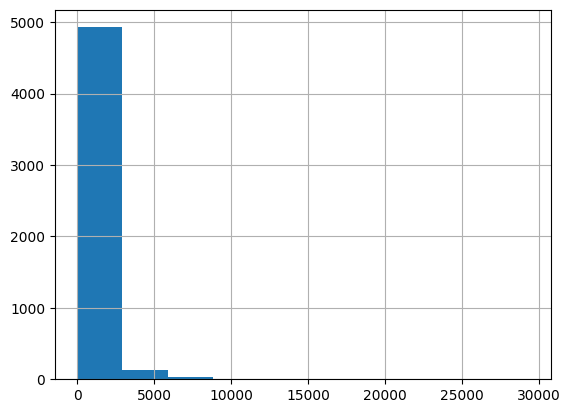

In [ ]:
plt.hist(clientes['qtdePontos'])
plt.grid(True)
plt.show()

Distribuição totalmente assimétrica. A ideia de logaritmos natural e justamente deixar menos assimétrica esta distribuição. Ou seja, se tornar mais próximo de uma distribuição normal.

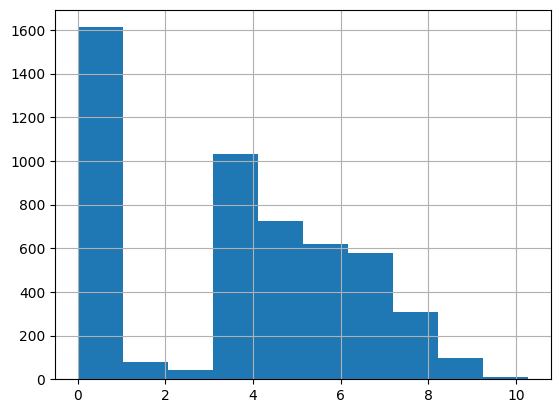

In [378]:
plt.hist(clientes['pontos_log'])
plt.grid(True)
plt.show()

### Ordenação 

O uso da função ***max*** não é útil já que ele enumera apenas um dos maiores valores.

In [386]:
clientes['qtdePontos'].sort_values()

10          0
64          0
5095        0
22          0
17          0
        ...  
2568    16246
4344    22578
881     24096
1       25086
492     29325
Name: qtdePontos, Length: 5097, dtype: int64

Forma mais flexível, ou seja, Esta operação estou ordenando um dataframe, informando por qual a série servirá de referência na ordenação e depois ordenando pelos 5 com mais pontos.

In [389]:
clientes.sort_values(by='qtdePontos', ascending=False).head()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
492,163022e8-12b8-486f-8604-57d8fa0ed7e1,0,1,0,0,0,29325,2025-02-19 13:11:26.517,2026-03-12 13:28:26.203,1,10.286230
1,000ff655-fa9f-4baa-a108-47f581ec52a1,0,0,0,0,0,25086,2024-02-01 00:00:00.000,2025-09-26 13:28:37.697,0,10.130105
881,2a9d4ba3-4c58-47f9-8dc4-6f9cb50be1b1,1,1,0,0,0,24096,2025-03-07 12:59:11.756,2026-03-12 11:57:35.241,2,10.089843
4344,d7f7eb75-4f0b-4d15-960d-8efe5ca7dd7e,0,0,0,0,0,22578,2025-03-07 12:36:50.254,2026-03-12 12:06:19.192,0,10.024776
2568,803debdb-8136-4cb5-af29-dcd8db36bf2c,0,1,0,0,0,16246,2025-02-28 13:19:26.475,2025-07-02 13:44:45.438,1,9.695664


Caso haja um empate e se queira escolher mais outra série como parâmetro.

Se passa por uma lista com os valores das séries e outra com a ordenação. 

In [391]:
clientes.sort_values(by=['DtCriacao','quantidade_redes_sociais'], ascending=[False, True]).head()

,idCliente,flEmail,flTwitch,flYouTube,flBlueSky,flInstagram,qtdePontos,DtCriacao,DtAtualizacao,quantidade_redes_sociais,pontos_log
467,1513fe6a-8cf9-4c58-ab04-3732d21aeb3b,0,1,0,0,0,0,2026-03-12 21:24:03.234,2026-03-12 21:24:03.234,1,0.0
2174,6c43f2e9-0d02-4047-8152-72f10936df95,1,1,1,0,0,0,2026-03-12 20:34:18.679,2026-03-12 20:34:52.176,3,0.0
1362,42f49900-86cb-40d3-9336-d621b95fd6cc,1,1,1,0,0,0,2026-03-12 15:24:32.575,2026-03-12 15:25:08.196,3,0.0
1839,5b042c75-a6c2-4cc5-b7df-5ffbb561c665,0,1,0,0,0,0,2026-03-12 06:25:12.488,2026-03-12 06:25:12.488,1,0.0
1870,5c6d43de-6aea-4106-959c-f7a0cf6d7243,0,1,0,0,0,0,2026-03-12 01:49:20.847,2026-03-12 01:49:20.847,1,0.0
